# **Linear Regression2**

### 1) 실습 개요
이번 실습에서는 경사하강법과 에폭에 대한 이해를 바탕으로 PyTorch에서 데이터를 표준화하고, 이를 확률적 경사하강법으로 학습하며, 새로운 데이터를 바탕으로 테스트를 진행합니다.

### 2) 실습 진행 목적 및 배경
경사하강법은 머신러닝 모델의 학습을 가능하게 해주는 중요한 기법중 하나입니다. 데이터를 표준화함으로써 학습이 안정적으로 진행되게끔 하고, 경사하강법과 에폭에 대한 개념적 이해를 바탕으로 슬기롭게 모델을 학습하는 방법을 배웁니다.

### 3) 실습 수행으로 얻어갈 수 있는 역량
- StandardScaler를 통해 적절히 데이터를 표준화할 수 있다.
- 확률적 경사하강법을 위한 옵티마이저 객체를 선언하고 이를 수행할 수 있다.
- 특정 에폭만큼 학습이 진행되도록 코드를 구현할 수 있다.

### 4) 실습 핵심 내용
&nbsp;&nbsp; 1.4 StandardScaler 클래스를 활용한 데이터 표준화<br>
&nbsp;&nbsp; 1.2 확률적 경사하강법<br>
&nbsp;&nbsp; 1.3 에폭<br>

### 5) 데이터셋 개요 및 저작권 정보

- 사용 데이터셋: [Salary Dataset](https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression)
  - 연차(YearsExperience)에 따른 임금(Salary) 데이터셋입니다.
- 저작권 정보: [CC0 1.0 Universal](https://creativecommons.org/publicdomain/zero/1.0/)

### 6) Required Package
```python
torch >= 2.3.0
pandas >= 2.0.3
scikit-learn >= 1.2.2
matplotlib >= 3.7.1
numpy >= 1.25.2
```

In [3]:
import torch

In [4]:
# Donwload dataset from kaggle
!kaggle datasets download -d abhishek14398/salary-dataset-simple-linear-regression
# unzip zip file
!unzip salary-dataset-simple-linear-regression.zip

Dataset URL: https://www.kaggle.com/datasets/abhishek14398/salary-dataset-simple-linear-regression
License(s): CC0-1.0
  0% 0.00/457 [00:00<?, ?B/s]
100% 457/457 [00:00<00:00, 646kB/s]
Archive:  salary-dataset-simple-linear-regression.zip
  inflating: Salary_dataset.csv      


In [6]:
# 트레이닝 데이터의 코드 표현

import pandas as pd
data = pd.read_csv("Salary_dataset.csv", sep = ",", header = 0) # 데이터 불러오기
# 특징 변수와 목적 변수로 분리

x = data.iloc[:, 1].values # 두 번째 열을 특징 변수로 사용 (YearsExperience)
t = data.iloc[:, 2].values # 세 번째 열을 목적 변수로 사용 (Salary)

# **1. 경사하강법**

**1.4 데이터 표준화**

In [11]:
# 데이터 표준화의 코드 표현 실습

from sklearn.preprocessing import StandardScaler

scaler_x = StandardScaler()
x_scaled = scaler_x.fit_transform(x.reshape(-1, 1))

scaler_t = StandardScaler()
t_scaled = scaler_t.fit_transform(t.reshape(-1, 1))

print(x_scaled)
print(t_scaled)

[[-1.51005294]
 [-1.43837321]
 [-1.36669348]
 [-1.18749416]
 [-1.11581443]
 [-0.86493538]
 [-0.82909552]
 [-0.75741579]
 [-0.75741579]
 [-0.57821647]
 [-0.50653674]
 [-0.47069688]
 [-0.47069688]
 [-0.43485702]
 [-0.29149756]
 [-0.1481381 ]
 [-0.07645838]
 [-0.00477865]
 [ 0.21026054]
 [ 0.2461004 ]
 [ 0.53281931]
 [ 0.6403389 ]
 [ 0.92705781]
 [ 1.03457741]
 [ 1.21377673]
 [ 1.32129632]
 [ 1.50049564]
 [ 1.5363355 ]
 [ 1.78721455]
 [ 1.85889428]]
[[-1.36011263]
 [-1.10552744]
 [-1.419919  ]
 [-1.20495739]
 [-1.33978143]
 [-0.71830716]
 [-0.58815781]
 [-0.79981746]
 [-0.42881019]
 [-0.69801306]
 [-0.47433279]
 [-0.74976858]
 [-0.70662043]
 [-0.70201994]
 [-0.55250402]
 [-0.29921736]
 [-0.37004264]
 [ 0.26285865]
 [ 0.19885989]
 [ 0.66547573]
 [ 0.58377993]
 [ 0.82623317]
 [ 0.93861127]
 [ 1.40274136]
 [ 1.24020308]
 [ 1.09740238]
 [ 1.51986835]
 [ 1.3590738 ]
 [ 1.72102849]
 [ 1.70177321]]


In [ ]:
# 데이터를 표준화한 numpy 배열을 Tensor로 변환

x_tensor = torch.tensor(x_scaled, dtype=torch.float32).view(-1, 1)  # 2차원 형태로 변환
t_tensor = torch.tensor(t_scaled, dtype=torch.float32).view(-1, 1)

In [ ]:
# 선형 회귀 모델 코드 표현 실습

import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super(LinearRegressionModel, self).__init__()
        self.linear = nn.Linear(1, 1)  # 입력과 출력이 모두 1개인 선형 회귀 모델

    def forward(self, x):
        y = self.linear(x) # 입력 데이터를 선형 계층을 통해 예측값 계산
        return y

# 인스턴스 생성

model = LinearRegressionModel()

In [ ]:
# GPU 지원

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
x_tensor = x_tensor.to(device)
t_tensor = t_tensor.to(device)

**1.2 확률적 경사하강법**

In [ ]:
# 확률적 경사하강법 코드 표현 실습
# 손실 함수 및 옵티마이저 정의

import torch.optim as optim

loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr = 0.01)  # 학습률을 적절히 설정

**1.3 에폭**

In [ ]:
# 에폭 코드 표현 실습
# 모델 반복 학습

num_epochs = 1000  # 에폭 수를 증가
loss_list = []  # 손실 값을 저장할 리스트

In [ ]:
for epoch in range(num_epochs):
    y = model(x_tensor)  # 예측 변수 계산
    loss = loss_function(y, t_tensor)  # 손실 값 계산

    # 확률적 경사하강법 작동원리의 코드 표현 실습

    optimizer.zero_grad()  # 이전 단계에서 계산된 경사(기울기)를 0으로 초기화
    loss.backward()  # 현재 손실(loss)에 대한 경사(기울기)를 계산 (역전파 수행)
    optimizer.step()  # 계산된 경사(기울기)를 사용하여 가중치를 업데이트

    # 손실 값을 저장

    loss_list.append(loss.item())

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item()}')

        # 디버깅 정보 출력

        for name, param in model.named_parameters():
            print(f'{name}: {param.data}')

Epoch [100/1000], Loss: 0.0809985026717186
linear.weight: tensor([[0.7995]])
linear.bias: tensor([0.0671])
Epoch [200/1000], Loss: 0.04371089115738869
linear.weight: tensor([[0.9545]])
linear.bias: tensor([0.0089])
Epoch [300/1000], Loss: 0.04305507242679596
linear.weight: tensor([[0.9751]])
linear.bias: tensor([0.0012])
Epoch [400/1000], Loss: 0.04304354265332222
linear.weight: tensor([[0.9778]])
linear.bias: tensor([0.0002])
Epoch [500/1000], Loss: 0.043043337762355804
linear.weight: tensor([[0.9782]])
linear.bias: tensor([2.0745e-05])
Epoch [600/1000], Loss: 0.043043334037065506
linear.weight: tensor([[0.9782]])
linear.bias: tensor([2.7473e-06])
Epoch [700/1000], Loss: 0.043043334037065506
linear.weight: tensor([[0.9782]])
linear.bias: tensor([3.6357e-07])
Epoch [800/1000], Loss: 0.043043334037065506
linear.weight: tensor([[0.9782]])
linear.bias: tensor([5.0042e-08])
Epoch [900/1000], Loss: 0.043043334037065506
linear.weight: tensor([[0.9782]])
linear.bias: tensor([2.1832e-08])
Epoc

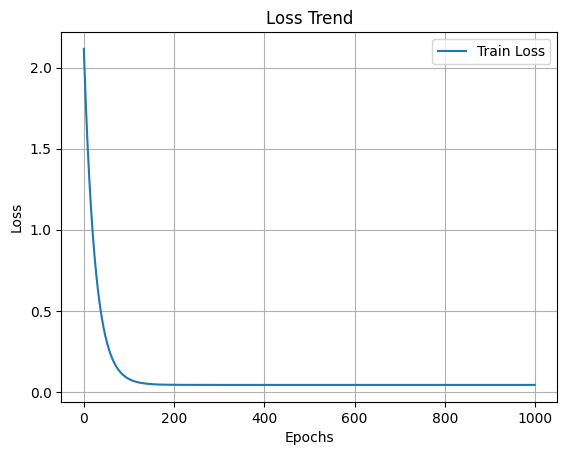

In [ ]:
# 손실 값의 변화를 시각화

import matplotlib.pyplot as plt

plt.figure()
plt.plot(loss_list, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.title('Loss Trend')
plt.show()

## 콘텐츠 라이선스

<hr style="height:5px;border:none;color:#5F71F7;background-color:#5F71F7">

<font color='red'><b>WARNING</font> : 본 교육 콘텐츠의 지식재산권은 재단법인 네이버커넥트에 귀속됩니다. 본 콘텐츠를 어떠한 경로로든 외부로 유출 및 수정하는 행위를 엄격히 금합니다. 다만, 비영리적 교육 및 연구활동에 한정되어 사용할 수 있으나 재단의 허락을 받아야 합니다. 이를 위반하는 경우, 관련 법률에 따라 책임을 질 수 있습니다. </b>